In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [41]:
# Import necessary libraries
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

In [6]:
# Step 1: Load the datasets
train_df = pd.read_csv('train.csv')  # Load the training dataset
test_df = pd.read_csv('test.csv')    # Load the test dataset

In [7]:
# Step 2: Handle missing values (numerical columns)
numerical_columns = ['Age', 'Income', 'WaistCirc', 'BMI', 'UrAlbCr', 'UricAcid', 'BloodGlucose', 'HDL', 'Triglycerides']
for col in numerical_columns:
    median_value = train_df[col].median()  # Calculate median for each numerical column
    train_df[col].fillna(median_value, inplace=True)  # Replace missing values with the median

C:\Users\ahmed\AppData\Local\Temp\ipykernel_4376\2712407099.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[col].fillna(median_value, inplace=True)  # Replace missing values with the median
C:\Users\ahmed\AppData\Local\Temp\ipykernel_4376\2712407099.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFr

In [8]:
# Handle missing values (categorical columns)
categorical_columns = ['Sex', 'Marital', 'Race']
for col in categorical_columns:
    mode_value = train_df[col].mode()[0]  # Get the most frequent value for each categorical column
    train_df[col].fillna(mode_value, inplace=True)  # Replace missing values with the mode (most frequent value)

C:\Users\ahmed\AppData\Local\Temp\ipykernel_4376\3967017210.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[col].fillna(mode_value, inplace=True)  # Replace missing values with the mode (most frequent value)


In [9]:
# Step 3: OneHotEncoding for categorical columns
encoder = OneHotEncoder(sparse_output=False)  # Initialize the encoder
encoded_columns = encoder.fit_transform(train_df[categorical_columns])  # Apply encoding to categorical columns
encoded_df = pd.DataFrame(encoded_columns, columns=encoder.get_feature_names_out(categorical_columns))  # Convert to DataFrame
train_df = pd.concat([train_df, encoded_df], axis=1)  # Concatenate the encoded columns with the original dataset
train_df.drop(columns=categorical_columns, inplace=True)  # Drop the original categorical columns after encoding

In [10]:
# Step 4: Split data into features (X) and target (y)
X = train_df.drop('MetabolicSyndrome', axis=1)  # Drop the target column
y = train_df['MetabolicSyndrome']  # Set the target column

In [11]:
# Step 5: Split into Training and Validation sets (80% training, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)  # Split the data

In [12]:
# Step 6: Handle missing values in X_train and X_val using SimpleImputer
imputer = SimpleImputer(strategy='mean')  # Initialize the imputer with 'mean' strategy
X_train_imputed = imputer.fit_transform(X_train)  # Apply imputation to the training data
X_val_imputed = imputer.transform(X_val)  # Apply imputation to the validation data

In [13]:
# Step 7: Scale the features using StandardScaler
scaler = StandardScaler()  # Initialize the scaler
X_train_scaled = scaler.fit_transform(X_train_imputed)  # Fit and transform the training data
X_val_scaled = scaler.transform(X_val_imputed)  # Transform the validation data using the same scaler

In [14]:
# Step 8: Train the Naive Bayes model
nb_model = GaussianNB()  # Initialize the Naive Bayes model
nb_model.fit(X_train_scaled, y_train)  # Train the model on the scaled training data
y_val_pred_nb = nb_model.predict(X_val_scaled)  # Make predictions on the validation set


kNN Performance for k=3:
Accuracy: 0.7526
Precision: 0.6870
Recall: 0.5725
F1-Score: 0.6245
Specificity: 0.8537


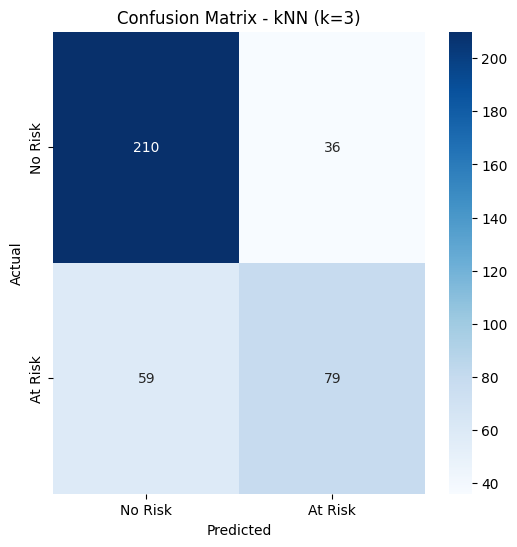

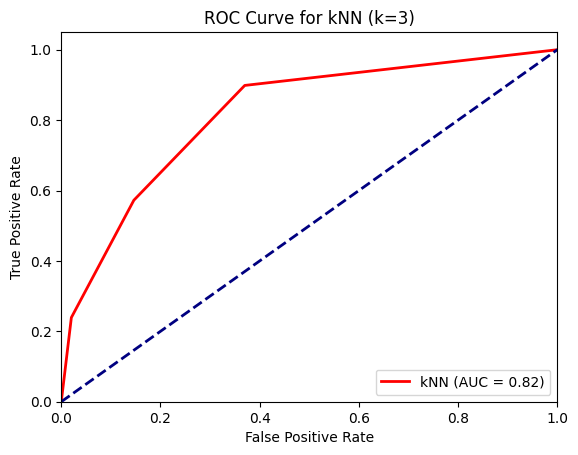


kNN Performance for k=5:
Accuracy: 0.7760
Precision: 0.7600
Recall: 0.5507
F1-Score: 0.6387
Specificity: 0.9024


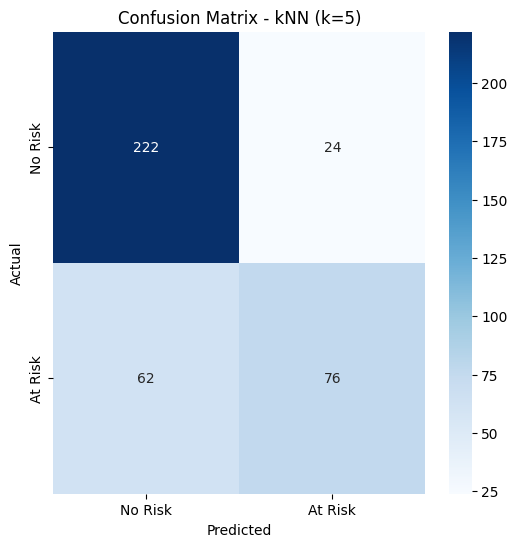

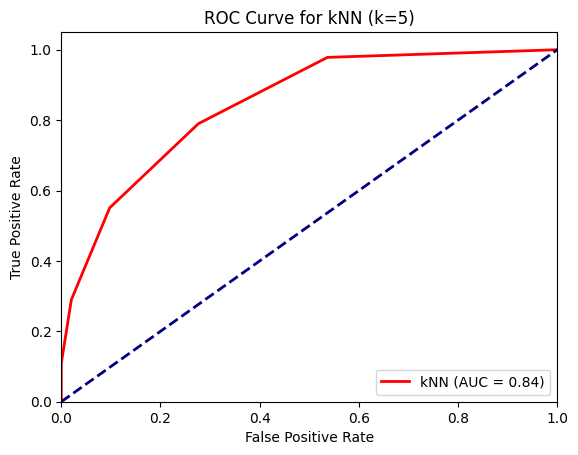


kNN Performance for k=7:
Accuracy: 0.7682
Precision: 0.8025
Recall: 0.4710
F1-Score: 0.5936
Specificity: 0.9350


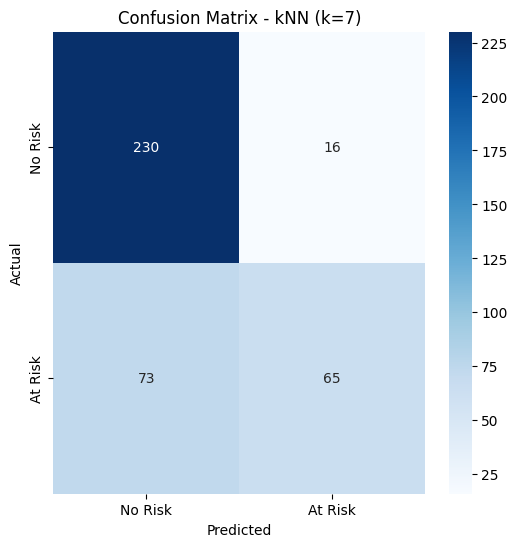

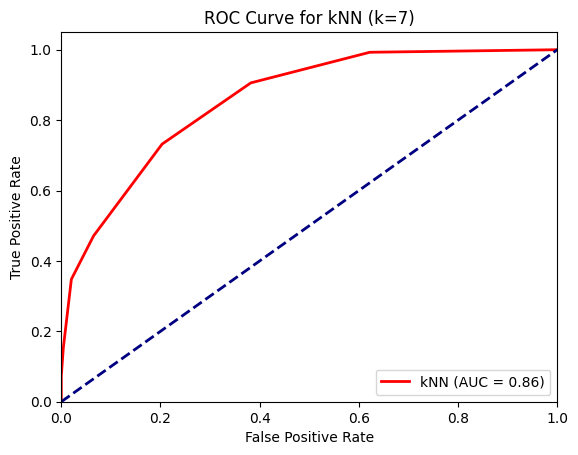


kNN Performance for k=9:
Accuracy: 0.7760
Precision: 0.8023
Recall: 0.5000
F1-Score: 0.6161
Specificity: 0.9309


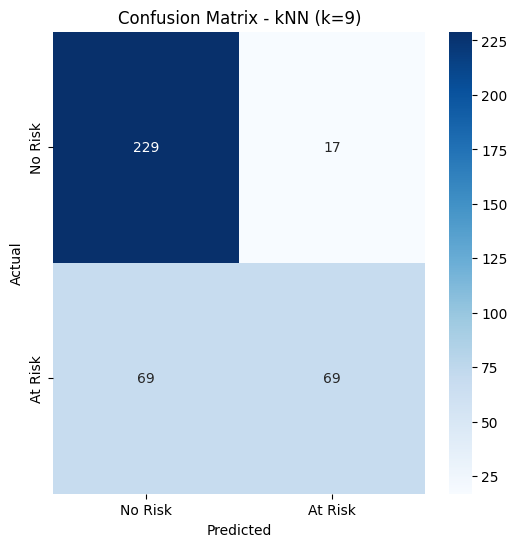

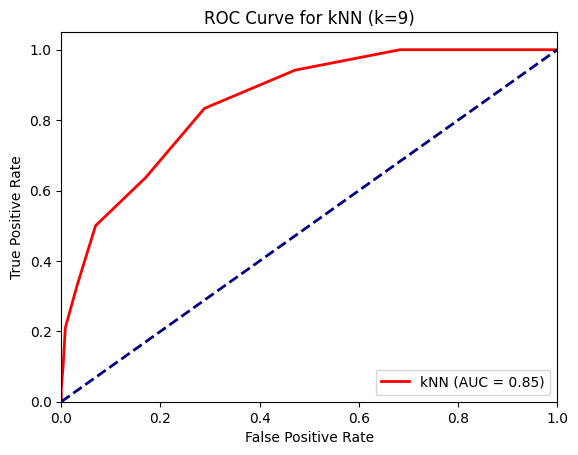


kNN Performance for k=11:
Accuracy: 0.7656
Precision: 0.8000
Recall: 0.4638
F1-Score: 0.5872
Specificity: 0.9350


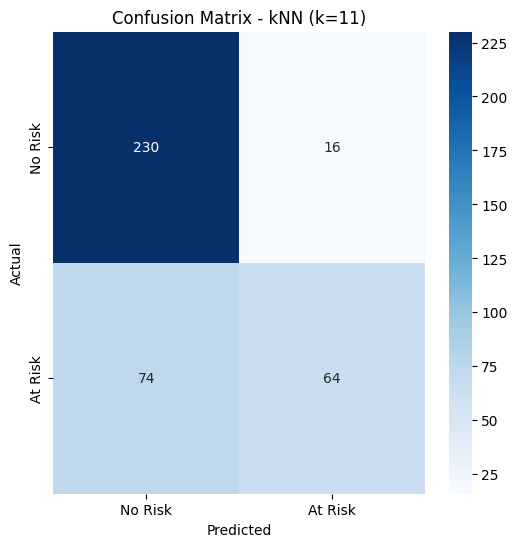

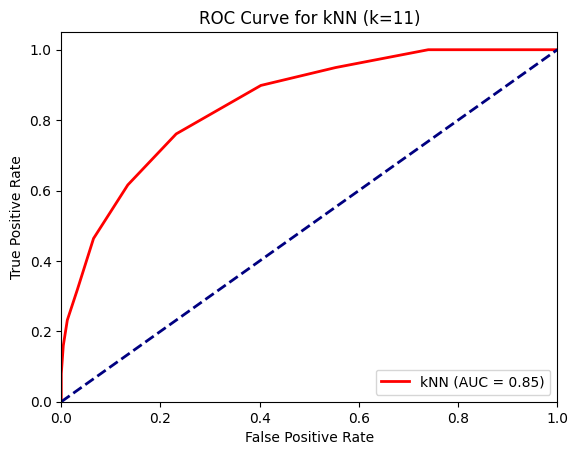


Best k value: 5 with accuracy: 0.7760


In [51]:
# Step: Find the best k based on accuracy
best_k = None
best_accuracy = 0

# Loop through different k values to find the best k
for k in k_values:
    # Initialize and train the kNN model with the current k
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_scaled, y_train)  # Train the model
    y_val_pred_knn = knn_model.predict(X_val_scaled)  # Make predictions on the validation set

    # Evaluate various metrics for the current k
    accuracy_knn = accuracy_score(y_val, y_val_pred_knn)
    precision_knn = precision_score(y_val, y_val_pred_knn)
    recall_knn = recall_score(y_val, y_val_pred_knn)
    f1_knn = f1_score(y_val, y_val_pred_knn)

    # Compute Specificity from confusion matrix
    cm_knn = confusion_matrix(y_val, y_val_pred_knn)
    TN, FP, FN, TP = cm_knn.ravel()  # Get values from confusion matrix
    specificity_knn = TN / (TN + FP)  # Calculate specificity

    # Print individual metrics for kNN
    print(f"\nkNN Performance for k={k}:")
    print(f"Accuracy: {accuracy_knn:.4f}")
    print(f"Precision: {precision_knn:.4f}")
    print(f"Recall: {recall_knn:.4f}")
    print(f"F1-Score: {f1_knn:.4f}")
    print(f"Specificity: {specificity_knn:.4f}")

    # Generate confusion matrix plot
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=["No Risk", "At Risk"], yticklabels=["No Risk", "At Risk"])
    plt.title(f"Confusion Matrix - kNN (k={k})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Plot ROC curve for kNN
    fpr_knn, tpr_knn, _ = roc_curve(y_val, knn_model.predict_proba(X_val_scaled)[:, 1])
    roc_auc_knn = auc(fpr_knn, tpr_knn)
    plt.figure()
    plt.plot(fpr_knn, tpr_knn, color='red', lw=2, label=f'kNN (AUC = {roc_auc_knn:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for kNN (k={k})')
    plt.legend(loc="lower right")
    plt.show()

    # Update the best k if the current accuracy is higher
    if accuracy_knn > best_accuracy:
        best_accuracy = accuracy_knn
        best_k = k

# After loop ends, print the best k and its accuracy
print(f"\nBest k value: {best_k} with accuracy: {best_accuracy:.4f}")

In [52]:
# Step 10: Evaluate models
accuracy_nb = accuracy_score(y_val, y_val_pred_nb)  # Calculate accuracy for Naive Bayes
accuracy_knn = accuracy_score(y_val, y_val_pred_knn)  # Calculate accuracy for kNN

# Confusion Matrix for Naive Bayes and kNN
cm_nb = confusion_matrix(y_val, y_val_pred_nb)  # Calculate confusion matrix for Naive Bayes
cm_knn = confusion_matrix(y_val, y_val_pred_knn)  # Calculate confusion matrix for kNN

# Extract values from confusion matrix (True Negatives, False Positives, False Negatives, True Positives)
TN_nb, FP_nb, FN_nb, TP_nb = cm_nb.ravel()  # Naive Bayes confusion matrix
TN_knn, FP_knn, FN_knn, TP_knn = cm_knn.ravel()  # kNN confusion matrix

# Calculate Specificity (True Negative Rate) for both models
specificity_nb = TN_nb / (TN_nb + FP_nb)  # Specificity for Naive Bayes
specificity_knn = TN_knn / (TN_knn + FP_knn)  # Specificity for kNN

# Print detailed performance metrics for Naive Bayes
print("\nNaive Bayes Performance Metrics:")
print(f"Accuracy: {accuracy_nb:.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred_nb):.4f}")
print(f"Recall: {recall_score(y_val, y_val_pred_nb):.4f}")
print(f"F1-Score: {f1_score(y_val, y_val_pred_nb):.4f}")
print(f"Specificity: {specificity_nb:.4f}")

# Print detailed performance metrics for kNN
print("\nkNN Performance Metrics:")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred_knn):.4f}")
print(f"Recall: {recall_score(y_val, y_val_pred_knn):.4f}")
print(f"F1-Score: {f1_score(y_val, y_val_pred_knn):.4f}")
print(f"Specificity: {specificity_knn:.4f}")


Naive Bayes Performance Metrics:
Accuracy: 0.7891
Precision: 0.7478
Recall: 0.6232
F1-Score: 0.6798
Specificity: 0.8821

kNN Performance Metrics:
Accuracy: 0.7656
Precision: 0.8000
Recall: 0.4638
F1-Score: 0.5872
Specificity: 0.9350


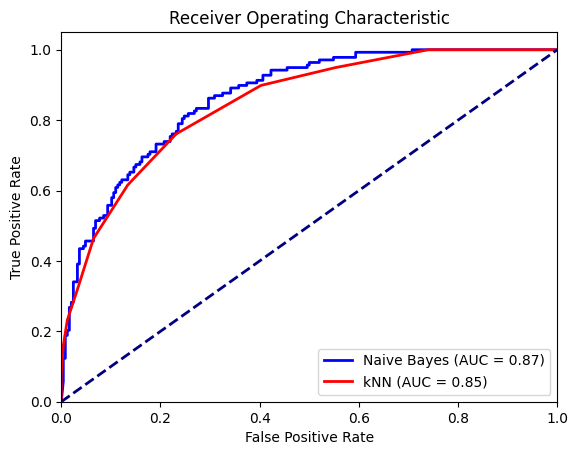

In [50]:
# Step 11: Plot ROC Curves for both models
fpr_nb, tpr_nb, _ = roc_curve(y_val, nb_model.predict_proba(X_val_scaled)[:, 1])  # Calculate ROC for Naive Bayes
roc_auc_nb = auc(fpr_nb, tpr_nb)  # Calculate AUC for Naive Bayes

fpr_knn, tpr_knn, _ = roc_curve(y_val, knn_model.predict_proba(X_val_scaled)[:, 1])  # Calculate ROC for kNN
roc_auc_knn = auc(fpr_knn, tpr_knn)  # Calculate AUC for kNN

plt.figure()  # Create a figure for plotting
plt.plot(fpr_nb, tpr_nb, color='blue', lw=2, label=f'Naive Bayes (AUC = {roc_auc_nb:.2f})')  # Plot ROC curve for Naive Bayes
plt.plot(fpr_knn, tpr_knn, color='red', lw=2, label=f'kNN (AUC = {roc_auc_knn:.2f})')  # Plot ROC curve for kNN
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Plot the diagonal line for random classifier
plt.xlim([0.0, 1.0])  # Set x-axis limits
plt.ylim([0.0, 1.05])  # Set y-axis limits
plt.xlabel('False Positive Rate')  # Label for x-axis
plt.ylabel('True Positive Rate')  # Label for y-axis
plt.title('Receiver Operating Characteristic')  # Title for the plot
plt.legend(loc="lower right")  # Display the legend
plt.show()  # Show the plot

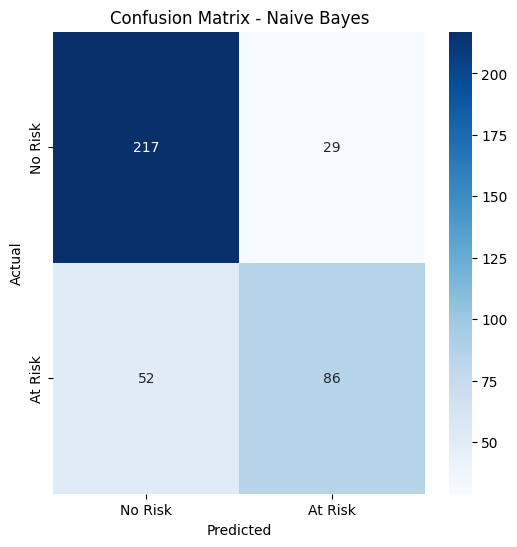

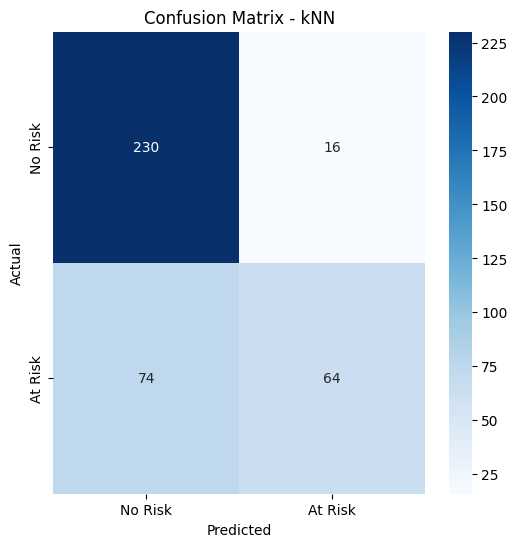

In [49]:
# Step 12: Confusion Matrices for Naive Bayes and kNN
cm_nb = confusion_matrix(y_val, y_val_pred_nb)  # Calculate confusion matrix for Naive Bayes
cm_knn = confusion_matrix(y_val, y_val_pred_knn)  # Calculate confusion matrix for kNN

# Plot confusion matrix for Naive Bayes
plt.figure(figsize=(6, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=["No Risk", "At Risk"], yticklabels=["No Risk", "At Risk"])
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Plot confusion matrix for kNN
plt.figure(figsize=(6, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=["No Risk", "At Risk"], yticklabels=["No Risk", "At Risk"])
plt.title("Confusion Matrix - kNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [53]:
# Step 13: Classification Report for Naive Bayes and kNN
print("Naive Bayes Classification Report:")
# Confusion Matrix for Naive Bayes
cm_nb = confusion_matrix(y_val, y_val_pred_nb)  
TN_nb, FP_nb, FN_nb, TP_nb = cm_nb.ravel()  # Get TN, FP, FN, TP for Naive Bayes
specificity_nb = TN_nb / (TN_nb + FP_nb)  # Calculate specificity for Naive Bayes

# Print performance metrics for Naive Bayes
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_nb):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred_nb):.4f}")
print(f"Recall: {recall_score(y_val, y_val_pred_nb):.4f}")
print(f"F1-Score: {f1_score(y_val, y_val_pred_nb):.4f}")
print(f"Specificity: {specificity_nb:.4f}")

print("\nkNN Classification Report:")
# Confusion Matrix for kNN
cm_knn = confusion_matrix(y_val, y_val_pred_knn)  
TN_knn, FP_knn, FN_knn, TP_knn = cm_knn.ravel()  # Get TN, FP, FN, TP for kNN
specificity_knn = TN_knn / (TN_knn + FP_knn)  # Calculate specificity for kNN

# Print performance metrics for kNN
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_knn):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred_knn):.4f}")
print(f"Recall: {recall_score(y_val, y_val_pred_knn):.4f}")
print(f"F1-Score: {f1_score(y_val, y_val_pred_knn):.4f}")
print(f"Specificity: {specificity_knn:.4f}")

Naive Bayes Classification Report:
Accuracy: 0.7891
Precision: 0.7478
Recall: 0.6232
F1-Score: 0.6798
Specificity: 0.8821

kNN Classification Report:
Accuracy: 0.7656
Precision: 0.8000
Recall: 0.4638
F1-Score: 0.5872
Specificity: 0.9350


In [48]:
# Step 14: Make predictions on the test set using the best model (Naive Bayes or kNN)
best_model = nb_model  # Choose the best model here (Naive Bayes or kNN)

# Ensure OneHotEncoding is applied to the test set the same way as the training set
X_test = test_df.drop(columns=['MetabolicSyndrome'], errors='ignore')  # Drop the target column if present in test set

# Apply OneHotEncoding to the categorical columns in the test set
encoded_columns_test = encoder.transform(X_test[categorical_columns])
encoded_df_test = pd.DataFrame(encoded_columns_test, columns=encoder.get_feature_names_out(categorical_columns))

# Concatenate the encoded columns with the test set
X_test = pd.concat([X_test, encoded_df_test], axis=1)

# Drop the original categorical columns after encoding
X_test.drop(columns=categorical_columns, inplace=True)

# Re-align the columns in X_test to match X_train (ensure both datasets have the same features)
X_test = X_test[X_train.columns]

# Scale the test data using the same scaler fitted on the training data
test_scaled = scaler.transform(X_test)

# Initialize the imputer with strategy='mean' to replace NaNs with the mean value
imputer = SimpleImputer(strategy='mean')

# Apply the imputer to the test set (same as done for training data)
X_test_imputed = imputer.fit_transform(X_test)  # Use fit_transform for test set to ensure no NaN values

# Scale the imputed test data using the same scaler fitted on the training data
test_scaled = scaler.transform(X_test_imputed)

# Make predictions on the test set
test_predictions = best_model.predict(test_scaled)

# Step 15: Save predictions to a CSV file for Kaggle submission
pd.DataFrame(test_predictions, columns=["Predicted"], index=test_df.index).to_csv("test_predictions.csv")

c:\Users\ahmed\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
